# Análisis individual de campaña — Gehring & Homberger
Notebook **parametrizado por tamaño**. Cambia `SIZE` en la primera celda y ejecuta todo (*Run All*) para analizar otra campaña (200 / 400 / 600 / 800 / 1000).

Produce: los gráficos de la campaña (en `figs/ghSIZE/`) y un **`resumen_ghSIZE.csv`** que luego consumirá el notebook de análisis de escala.

In [1]:
SIZE     = 600
MASTER   = f"../results/master_gh{SIZE}.csv"
BKS_FILE = f"../sintef/sintef_{SIZE}.csv"
OUTDIR   = f"../figs/gh{SIZE}"
RESUMEN  = f"../summary/resumen_gh{SIZE}.csv"

**Tiempos de ejecución por tamaño**

- **200 Clientes**: 10 instancias por familia, 60 instancias en total $\to$ 7h 13m 2.3s
- **400 Clientes**: 10 instancias por familia, 60 instancias en total $\to$ 16h 48h 59.9s
- **600 Clientes**: 10 instancias por familia, 60 instancias en total $\to$ 23h 37m 10.4s
- **800 Clientes**: 10 instancias por familia, 60 instancias en total $\to$ 31h 13m 12.5s

In [2]:
import os, math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import friedmanchisquare, wilcoxon

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 12
plt.rcParams['savefig.dpi'] = 300
os.makedirs(OUTDIR, exist_ok=True)

ORDEN_FAM = ['C1','C2','R1','R2','RC1','RC2']
C_ALNS, C_QL, C_BKS = '#e74c3c', '#2ecc71', '#7f8c8d'

### Carga del maestro y consolidación

In [3]:
df = pd.read_csv(MASTER)
df['instance'] = df['instance'].astype(str).str.lower().str.strip()

n_total = len(df)
df = df[df['valid'] == 1].copy()
print(f"Corridas: {n_total} | validas: {len(df)} | descartadas: {n_total - len(df)}")

df = df[df['size'] == SIZE].copy()

df_avg = (df.groupby(['instance','class','algorithm'])[['best_veh','best_dist','cpu_time']]
            .mean().reset_index())

ren = {'best_veh':'Vehiculos','best_dist':'Distancia','cpu_time':'Tiempo_s'}
df_pivot = df_avg.pivot(index=['instance','class'], columns='algorithm',
                        values=['best_veh','best_dist','cpu_time'])
df_pivot.columns = [f"{algo}_{ren[m]}" for m, algo in df_pivot.columns]
df_pivot = df_pivot.reset_index().rename(columns={'class':'Familia'})
df_pivot['Familia'] = df_pivot['Familia'].str.upper()
df_pivot.head()

Corridas: 1200 | validas: 1200 | descartadas: 0


,instance,Familia,CLASSIC_Vehiculos,QLEARNING_Vehiculos,CLASSIC_Distancia,QLEARNING_Distancia,CLASSIC_Tiempo_s,QLEARNING_Tiempo_s
0,c1_6_1,C1,60.7,60.7,14345.13,14359.04,57.86717,57.69218
1,c1_6_10,C1,56.7,56.3,14083.09,14129.10,72.47813,65.55155
2,c1_6_2,C1,58.8,58.3,14439.46,14506.20,73.33282,69.16251
3,c1_6_3,C1,56.1,56.0,14638.53,14414.18,72.05779,71.17031
4,c1_6_4,C1,56.0,56.0,14059.56,13971.93,68.66407,67.55156


### BKS, GAP $f_2$ y regla de auditoría
Se calcula el DIF de flota ($f_1$) y el GAP% de distancia ($f_2$) contra el BKS. 

**Regla de auditoría:** el GAP solo es válido si el algoritmo igualó o mejoró la flota del BKS (si usó más vehículos, el GAP se anula con `NaN`).

Si aún no tienes `gh_bks.csv`, el notebook igual corre: omite los análisis que dependen del BKS y ejecuta los de comparación directa ALNS vs ALNS-Q.

In [4]:
tiene_bks = os.path.exists(BKS_FILE)
df_final = df_pivot.copy()

if tiene_bks:
    df_bks = pd.read_csv(BKS_FILE)
    df_bks['instance'] = df_bks['instance'].astype(str).str.lower().str.strip()
    df_bks = df_bks[df_bks['size'] == SIZE][['instance','BKS_Veh','BKS_Dist']]
    df_final = pd.merge(df_final, df_bks, on='instance', how='left')
    for A in ['CLASSIC','QLEARNING']:
        df_final[f'{A}_DIF_f1'] = df_final[f'{A}_Vehiculos'] - df_final['BKS_Veh']
        gap = ((df_final[f'{A}_Distancia'] - df_final['BKS_Dist']) / df_final['BKS_Dist']) * 100
        df_final[f'{A}_GAP_f2(%)'] = np.where(df_final[f'{A}_Vehiculos'] > df_final['BKS_Veh'],
                                              np.nan, gap.clip(lower=0))
else:
    print("[AVISO] Sin gh_bks.csv: se omiten GAP y graficos que dependen del BKS.")

df_final['size'] = SIZE
df_final.to_csv(RESUMEN, index=False)
print(f"Resumen guardado en {RESUMEN}  ({len(df_final)} instancias)")
df_final.head()

Resumen guardado en ../summary/resumen_gh600.csv  (60 instancias)


,instance,Familia,CLASSIC_Vehiculos,QLEARNING_Vehiculos,CLASSIC_Distancia,QLEARNING_Distancia,CLASSIC_Tiempo_s,QLEARNING_Tiempo_s,BKS_Veh,BKS_Dist,CLASSIC_DIF_f1,CLASSIC_GAP_f2(%),QLEARNING_DIF_f1,QLEARNING_GAP_f2(%),size
0,c1_6_1,C1,60.7,60.7,14345.13,14359.04,57.86717,57.69218,60,14095.64,0.7,NaN,0.7,NaN,600
1,c1_6_10,C1,56.7,56.3,14083.09,14129.10,72.47813,65.55155,56,13637.34,0.7,NaN,0.3,NaN,600
2,c1_6_2,C1,58.8,58.3,14439.46,14506.20,73.33282,69.16251,56,14163.31,2.8,NaN,2.3,NaN,600
3,c1_6_3,C1,56.1,56.0,14638.53,14414.18,72.05779,71.17031,56,13777.81,0.1,NaN,0.0,4.618804,600
4,c1_6_4,C1,56.0,56.0,14059.56,13971.93,68.66407,67.55156,56,13558.54,0.0,3.695236,0.0,3.048927,600


### Éxito de minimización de flota $f_1$ por familia

In [5]:
if tiene_bks:
    df_final['CLASSIC_Exito_f1']   = df_final['CLASSIC_Vehiculos'] <= df_final['BKS_Veh']
    df_final['QLEARNING_Exito_f1'] = df_final['QLEARNING_Vehiculos'] <= df_final['BKS_Veh']
    df_exito = df_final.groupby('Familia').agg(
        Total=('instance','count'),
        CLASSIC_Exitos=('CLASSIC_Exito_f1','sum'),
        QLEARNING_Exitos=('QLEARNING_Exito_f1','sum')).reset_index()
    df_exito['CLASSIC_Tasa(%)']   = (df_exito['CLASSIC_Exitos']/df_exito['Total']*100).round(2)
    df_exito['QLEARNING_Tasa(%)'] = (df_exito['QLEARNING_Exitos']/df_exito['Total']*100).round(2)
    display(df_exito)
else:
    print("Requiere gh_bks.csv")

,Familia,Total,CLASSIC_Exitos,QLEARNING_Exitos,CLASSIC_Tasa(%),QLEARNING_Tasa(%)
0,C1,10,2,2,20.0,20.0
1,C2,10,0,0,0.0,0.0
2,R1,10,1,2,10.0,20.0
3,R2,10,7,7,70.0,70.0
4,RC1,10,1,3,10.0,30.0
5,RC2,10,2,2,20.0,20.0


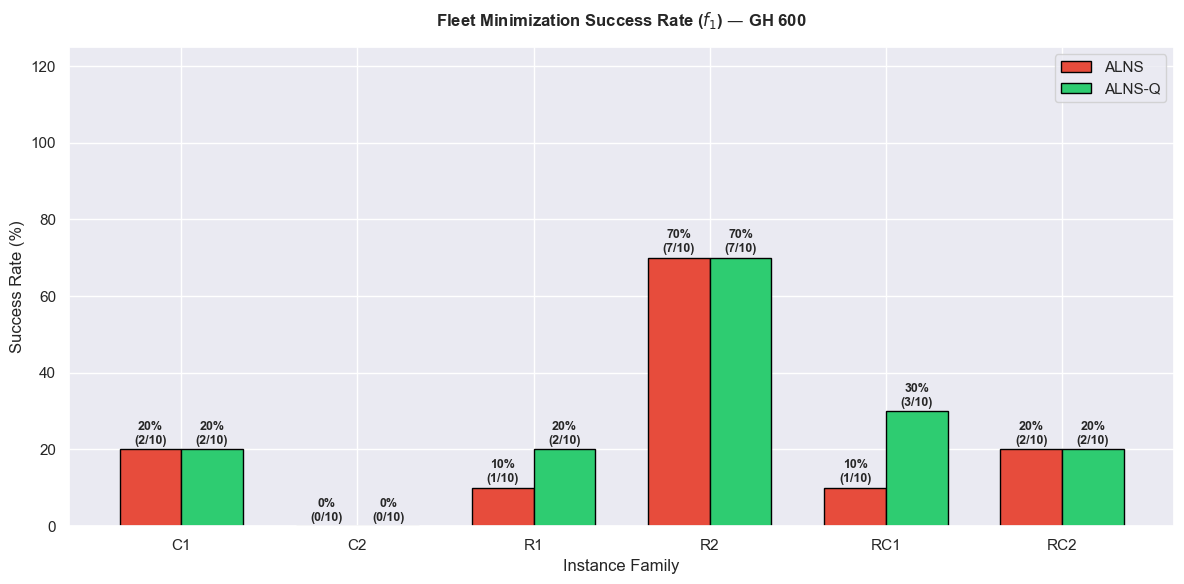

In [6]:
if tiene_bks:
    fams = df_exito['Familia']; x = np.arange(len(fams)); w = 0.35
    fig, ax = plt.subplots(figsize=(12,6))
    b1 = ax.bar(x-w/2, df_exito['CLASSIC_Tasa(%)'], w, label='ALNS', color=C_ALNS, edgecolor='black')
    b2 = ax.bar(x+w/2, df_exito['QLEARNING_Tasa(%)'], w, label='ALNS-Q', color=C_QL, edgecolor='black')
    ax.set_title(f'Fleet Minimization Success Rate ($f_1$) — GH {SIZE}', fontweight='bold', pad=15)
    ax.set_ylabel('Success Rate (%)'); ax.set_xlabel('Instance Family')
    ax.set_xticks(x); ax.set_xticklabels(fams); ax.set_ylim(0,125); ax.legend()
    for bars, ex, tot in [(b1, df_exito['CLASSIC_Exitos'], df_exito['Total']),
                          (b2, df_exito['QLEARNING_Exitos'], df_exito['Total'])]:
        for i,bar in enumerate(bars):
            h=bar.get_height()
            ax.annotate(f'{h:.0f}%\n({ex.iloc[i]}/{tot.iloc[i]})',(bar.get_x()+bar.get_width()/2,h),
                        xytext=(0,4),textcoords='offset points',ha='center',fontsize=9,fontweight='bold')
    plt.tight_layout(); plt.savefig(f"{OUTDIR}/f1_success.png", bbox_inches='tight'); plt.show()

### Asignación de flota $f_1$ por instancia (BKS vs ALNS vs ALNS-Q)

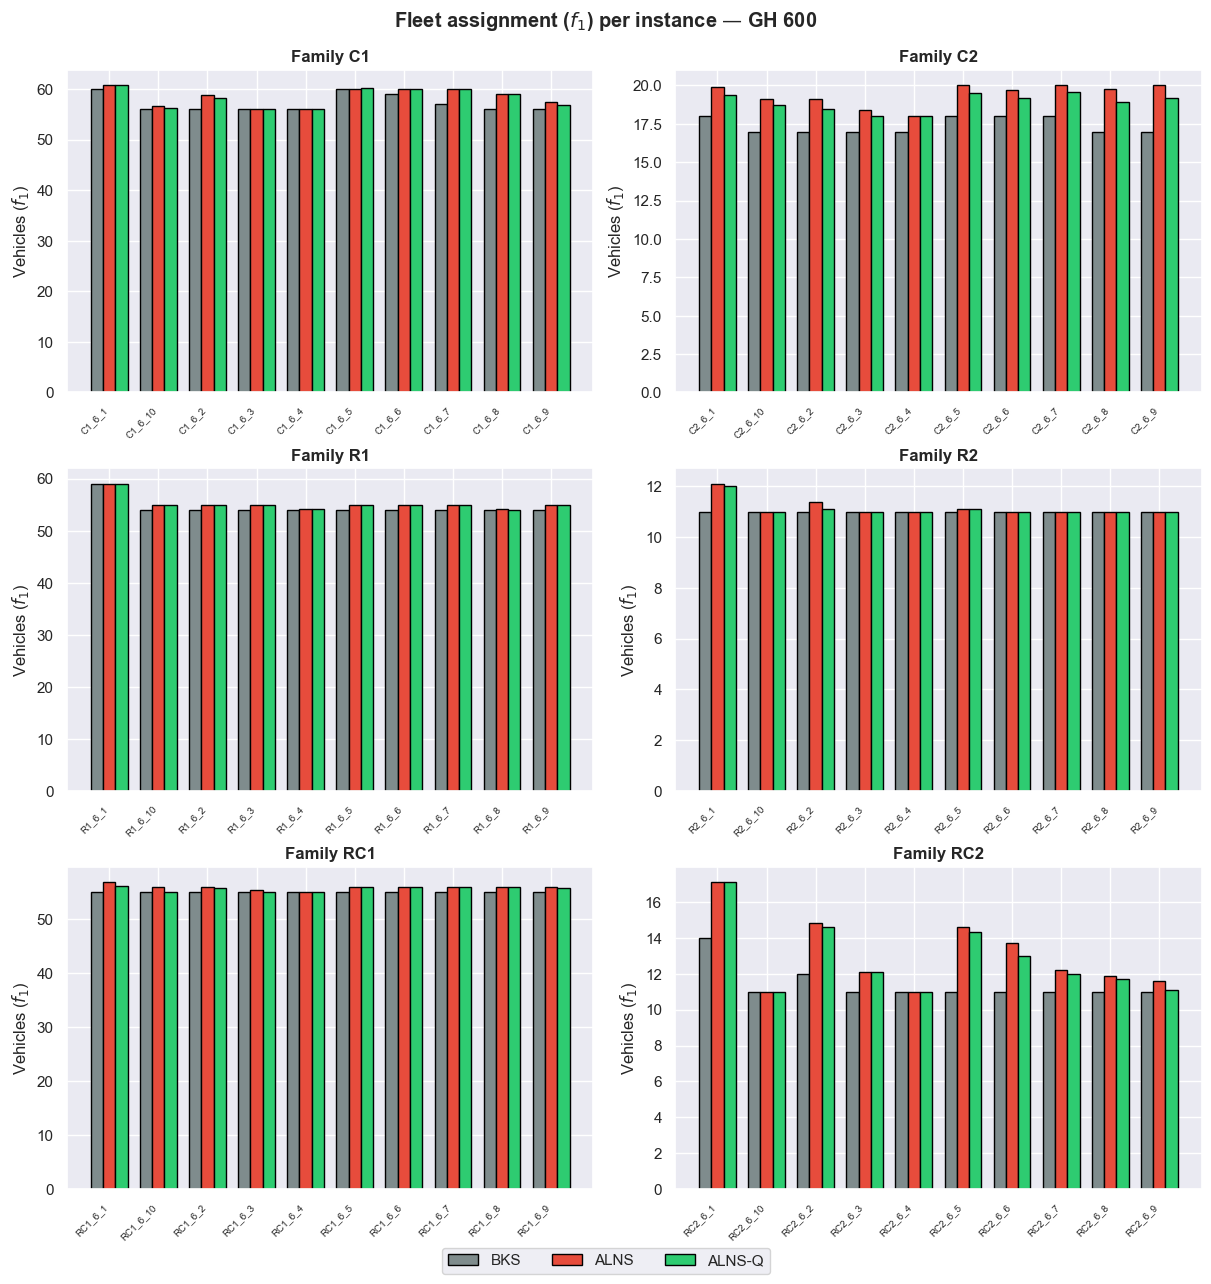

In [7]:
if tiene_bks:
    fams_var = [f for f in ORDEN_FAM if f in df_final['Familia'].unique()]
    ncols = 2; nrows = math.ceil(len(fams_var)/ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4*nrows), constrained_layout=True)
    axes = np.array(axes).flatten()
    for ax, fam in zip(axes, fams_var):
        d = df_final[df_final['Familia']==fam].sort_values('instance'); x=np.arange(len(d)); w=0.25
        ax.bar(x-w, d['BKS_Veh'], w, label='BKS', color=C_BKS, edgecolor='black')
        ax.bar(x,   d['CLASSIC_Vehiculos'], w, label='ALNS', color=C_ALNS, edgecolor='black')
        ax.bar(x+w, d['QLEARNING_Vehiculos'], w, label='ALNS-Q', color=C_QL, edgecolor='black')
        ax.set_title(f'Family {fam}', fontweight='bold'); ax.set_ylabel('Vehicles ($f_1$)')
        ax.set_xticks(x); ax.set_xticklabels(d['instance'].str.upper(), rotation=45, ha='right', fontsize=7)
    for ax in axes[len(fams_var):]: ax.set_visible(False)
    h,l = axes[0].get_legend_handles_labels()
    fig.legend(h,l, loc='lower center', ncol=3, bbox_to_anchor=(0.5,-0.03))
    plt.suptitle(f'Fleet assignment ($f_1$) per instance — GH {SIZE}', fontweight='bold', y=1.03)
    plt.savefig(f"{OUTDIR}/f1_panel.png", bbox_inches='tight'); plt.show()

### Calidad de ruta —  $\Delta f_2 $ porcentual

Comparativa directa entre algoritmos. Sólo cubren las instancias donde ambos igualan en vehículos utilizados ($f_1$).

Instancias con flota empatada (ALNS = ALNS-Q): 30 de 60


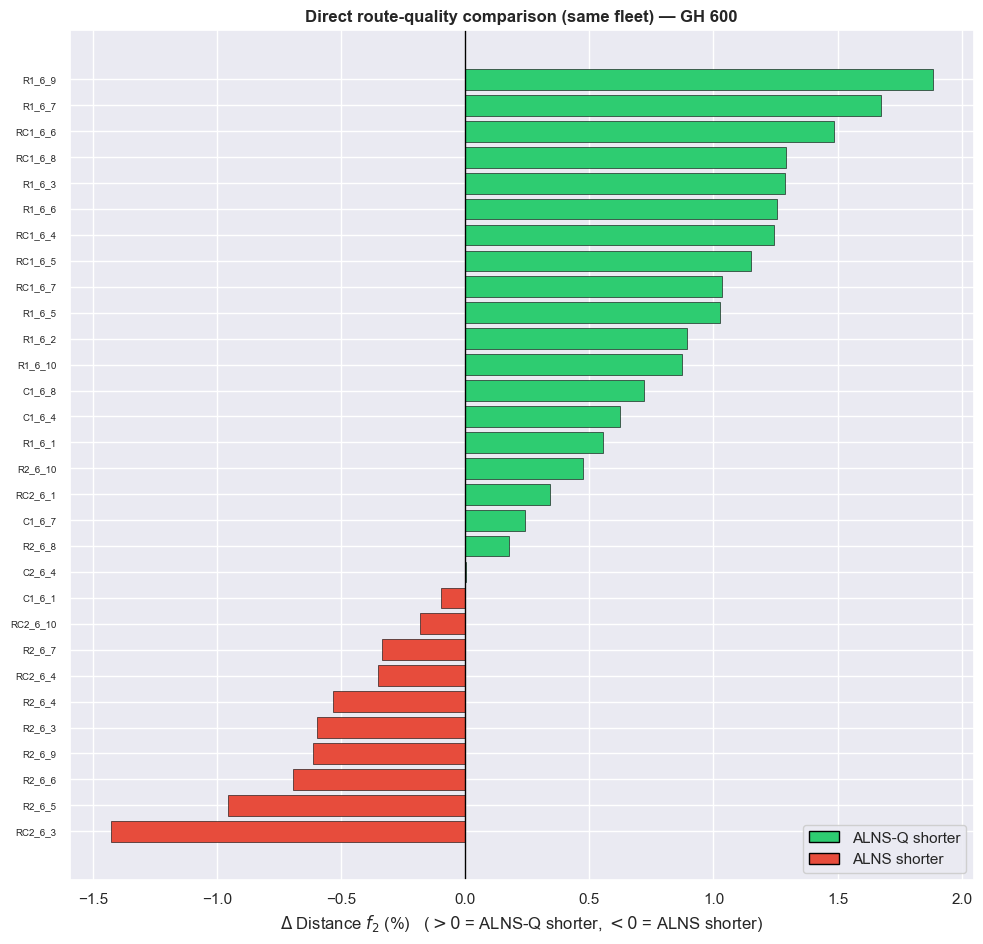

In [8]:
dd = df_final[df_final['CLASSIC_Vehiculos'] == df_final['QLEARNING_Vehiculos']].copy()
print(f"Instancias con flota empatada (ALNS = ALNS-Q): {len(dd)} de {len(df_final)}")

if len(dd) > 0:
    dd['dDist%'] = ((dd['CLASSIC_Distancia'] - dd['QLEARNING_Distancia']) / dd['CLASSIC_Distancia']) * 100
    dd = dd.sort_values('dDist%')
    y = np.arange(len(dd))
    colors = [C_QL if v > 0 else C_ALNS for v in dd['dDist%']]
    fig, ax = plt.subplots(figsize=(10, max(4, 0.32*len(dd))))
    ax.barh(y, dd['dDist%'], color=colors, edgecolor='black', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_yticks(y); ax.set_yticklabels(dd['instance'].str.upper(), fontsize=7)
    ax.set_xlabel('$\\Delta$ Distance $f_2$ (%)   ($>0$ = ALNS-Q shorter, $<0$ = ALNS shorter)')
    ax.set_title(f'Direct route-quality comparison (same fleet) — GH {SIZE}', fontweight='bold')
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor=C_QL, edgecolor='black', label='ALNS-Q shorter'),
                       Patch(facecolor=C_ALNS, edgecolor='black', label='ALNS shorter')],
              loc='lower right', framealpha=0.9)
    plt.tight_layout(); plt.savefig(f"{OUTDIR}/f2_direct.png", bbox_inches='tight'); plt.show()
else:
    print("Sin instancias de flota empatada para la comparativa directa.")

### Calidad de ruta — GAP $f_2$ (dumbbell)
Solo instancias donde **ambos** algoritmos igualaron la flota del BKS. El número de instancias válidas puede ser bajo en tamaños grandes: se reporta explícitamente.

Instancias con GAP f2 valido: 12 de 60


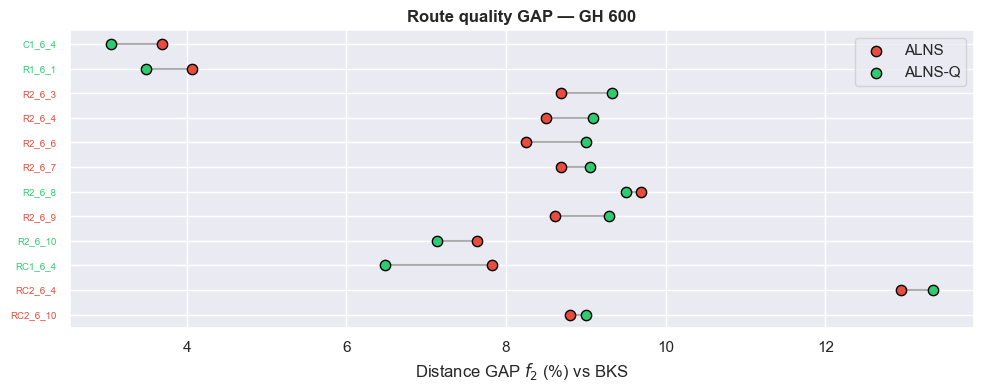

In [9]:
if tiene_bks:
    d = df_final.dropna(subset=['CLASSIC_GAP_f2(%)','QLEARNING_GAP_f2(%)']).copy()
    print(f"Instancias con GAP f2 valido: {len(d)} de {len(df_final)}")
    
    if len(d) > 0:
        d['__fam'] = d['Familia'].apply(lambda f: ORDEN_FAM.index(f) if f in ORDEN_FAM else 99)
        d['__idx'] = d['instance'].apply(lambda s: int(s.split('_')[-1]))
        d = d.sort_values(['__fam','__idx']).reset_index(drop=True)
        y = np.arange(len(d))
        fig, ax = plt.subplots(figsize=(10, max(4, 0.34*len(d))))
        ax.hlines(y, d['CLASSIC_GAP_f2(%)'], d['QLEARNING_GAP_f2(%)'], color='gray', alpha=0.6)
        ax.scatter(d['CLASSIC_GAP_f2(%)'], y, color=C_ALNS, label='ALNS', s=55, edgecolor='black', zorder=3)
        ax.scatter(d['QLEARNING_GAP_f2(%)'], y, color=C_QL, label='ALNS-Q', s=55, edgecolor='black', zorder=3)
        ax.set_yticks(y); ax.set_yticklabels(d['instance'].str.upper(), fontsize=7)

        for tick, (_, r) in zip(ax.get_yticklabels(), d.iterrows()):
            if r['QLEARNING_GAP_f2(%)'] < r['CLASSIC_GAP_f2(%)']:
                tick.set_color(C_QL)
            elif r['QLEARNING_GAP_f2(%)'] > r['CLASSIC_GAP_f2(%)']:
                tick.set_color(C_ALNS)
            else:
                tick.set_color('gray')
        ax.invert_yaxis()
        ax.set_xlabel('Distance GAP $f_2$ (%) vs BKS'); ax.set_title(f'Route quality GAP — GH {SIZE}', fontweight='bold')
        ax.legend(); plt.tight_layout(); plt.savefig(f"{OUTDIR}/f2_dumbbell.png", bbox_inches='tight'); plt.show()
    else:
        print("Sin instancias validas para el dumbbell en este tamano.")

### Paridad de GAP $f_2$ (por debajo de la diagonal = ALNS-Q mejor)

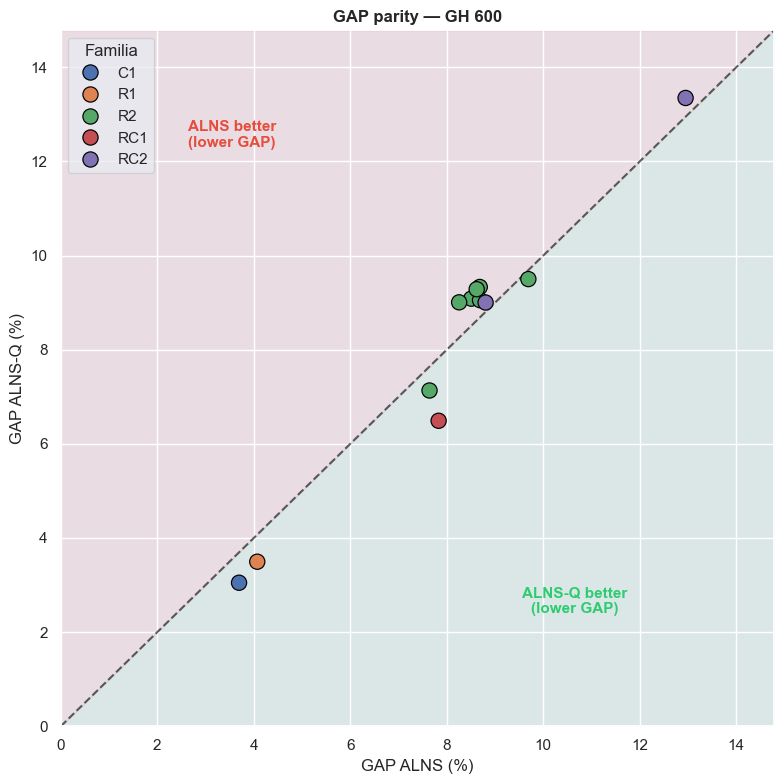

In [10]:
if tiene_bks:
    d = df_final.dropna(subset=['CLASSIC_GAP_f2(%)','QLEARNING_GAP_f2(%)'])
    
    if len(d) > 0:
        fig, ax = plt.subplots(figsize=(8,8))
        lim = max(d['CLASSIC_GAP_f2(%)'].max(), d['QLEARNING_GAP_f2(%)'].max())*1.1 + 0.1

        ax.fill_between([0,lim],[0,0],[0,lim], color=C_QL, alpha=0.08, zorder=0)

        ax.fill_between([0,lim],[0,lim],[lim,lim], color=C_ALNS, alpha=0.08, zorder=0)
        ax.plot([0,lim],[0,lim],'--',color='black',alpha=0.6, zorder=1)
        ax.text(lim*0.72, lim*0.18, 'ALNS-Q better\n(lower GAP)', color=C_QL,
                fontsize=11, fontweight='bold', ha='center', va='center')
        ax.text(lim*0.24, lim*0.85, 'ALNS better\n(lower GAP)', color=C_ALNS,
                fontsize=11, fontweight='bold', ha='center', va='center')
        sns.scatterplot(data=d, x='CLASSIC_GAP_f2(%)', y='QLEARNING_GAP_f2(%)', hue='Familia',
                        s=120, edgecolor='black', ax=ax, zorder=3)
        ax.set_xlim(0,lim); ax.set_ylim(0,lim)
        ax.set_xlabel('GAP ALNS (%)'); ax.set_ylabel('GAP ALNS-Q (%)')
        ax.set_title(f'GAP parity — GH {SIZE}', fontweight='bold')
        plt.tight_layout(); plt.savefig(f"{OUTDIR}/f2_parity.png", bbox_inches='tight'); plt.show()
    else:
        print("Sin instancias validas para la paridad en este tamano.")

### Marcador directo: ALNS-Q vs ALNS (orden lexicográfico)

In [11]:
def enfrentamiento(r):
    if r['QLEARNING_Vehiculos'] < r['CLASSIC_Vehiculos']: return 'Win'
    if r['QLEARNING_Vehiculos'] > r['CLASSIC_Vehiculos']: return 'Loss'
    if r['QLEARNING_Distancia'] < r['CLASSIC_Distancia']: return 'Win'
    if r['QLEARNING_Distancia'] > r['CLASSIC_Distancia']: return 'Loss'
    return 'Tie'

df_final['WTL'] = df_final.apply(enfrentamiento, axis=1)
marcador = pd.crosstab(df_final['Familia'], df_final['WTL'])
for c in ['Win','Tie','Loss']:
    if c not in marcador: marcador[c] = 0
marcador = marcador[['Win','Tie','Loss']]
marcador.loc['TOTAL'] = marcador.sum()
display(marcador)

WTL,Win,Tie,Loss
Familia,,,
C1,8,0,2
C2,10,0,0
R1,10,0,0
R2,4,0,6
RC1,10,0,0
RC2,7,0,3
TOTAL,49,0,11


### Distribución del tiempo de CPU por familia

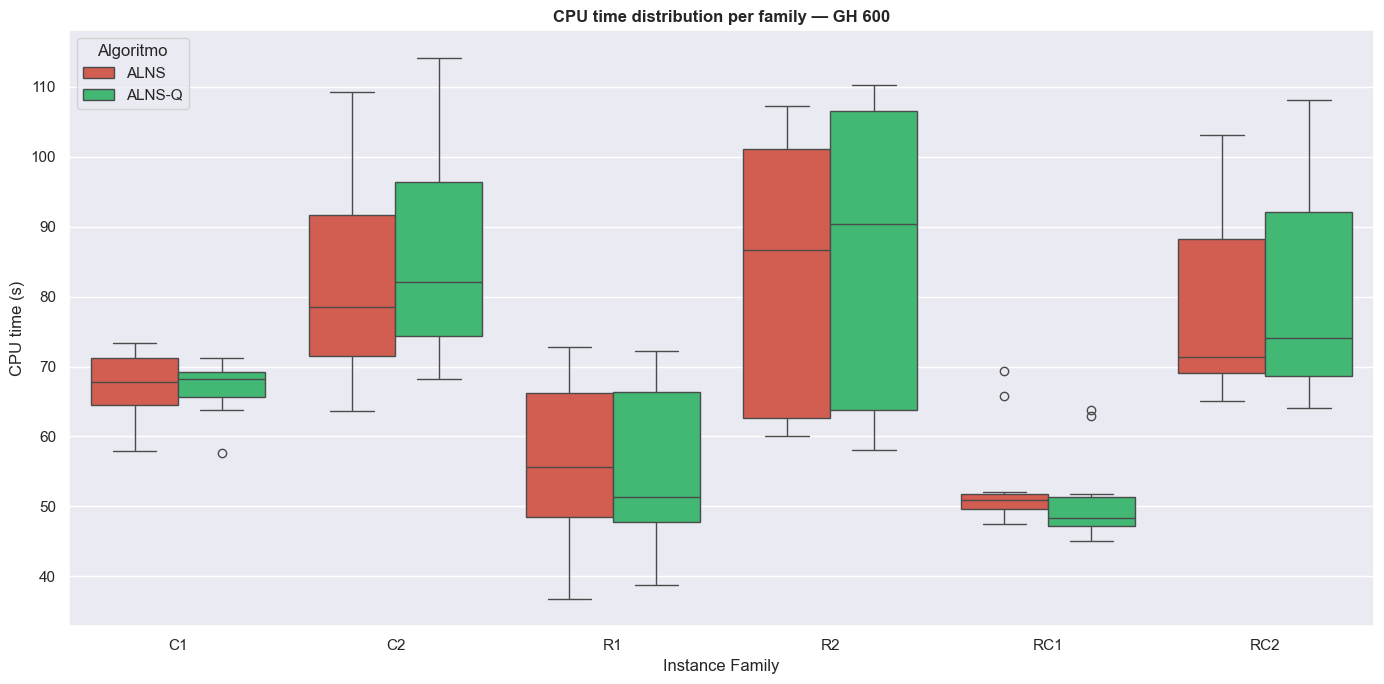

In [12]:
dc = df_final[['Familia','CLASSIC_Tiempo_s']].rename(columns={'CLASSIC_Tiempo_s':'Tiempo'}); dc['Algoritmo']='ALNS'
dq = df_final[['Familia','QLEARNING_Tiempo_s']].rename(columns={'QLEARNING_Tiempo_s':'Tiempo'}); dq['Algoritmo']='ALNS-Q'
dbox = pd.concat([dc,dq], ignore_index=True)
fig, ax = plt.subplots(figsize=(14,7))
sns.boxplot(data=dbox, x='Familia', y='Tiempo', hue='Algoritmo',
            order=[f for f in ORDEN_FAM if f in dbox['Familia'].unique()],
            palette=[C_ALNS,C_QL], ax=ax)
ax.set_title(f'CPU time distribution per family — GH {SIZE}', fontweight='bold')
ax.set_ylabel('CPU time (s)'); ax.set_xlabel('Instance Family')
plt.tight_layout(); plt.savefig(f"{OUTDIR}/time_dist.png", bbox_inches='tight'); plt.show()

### Trade-off computacional (instancias con misma flota)

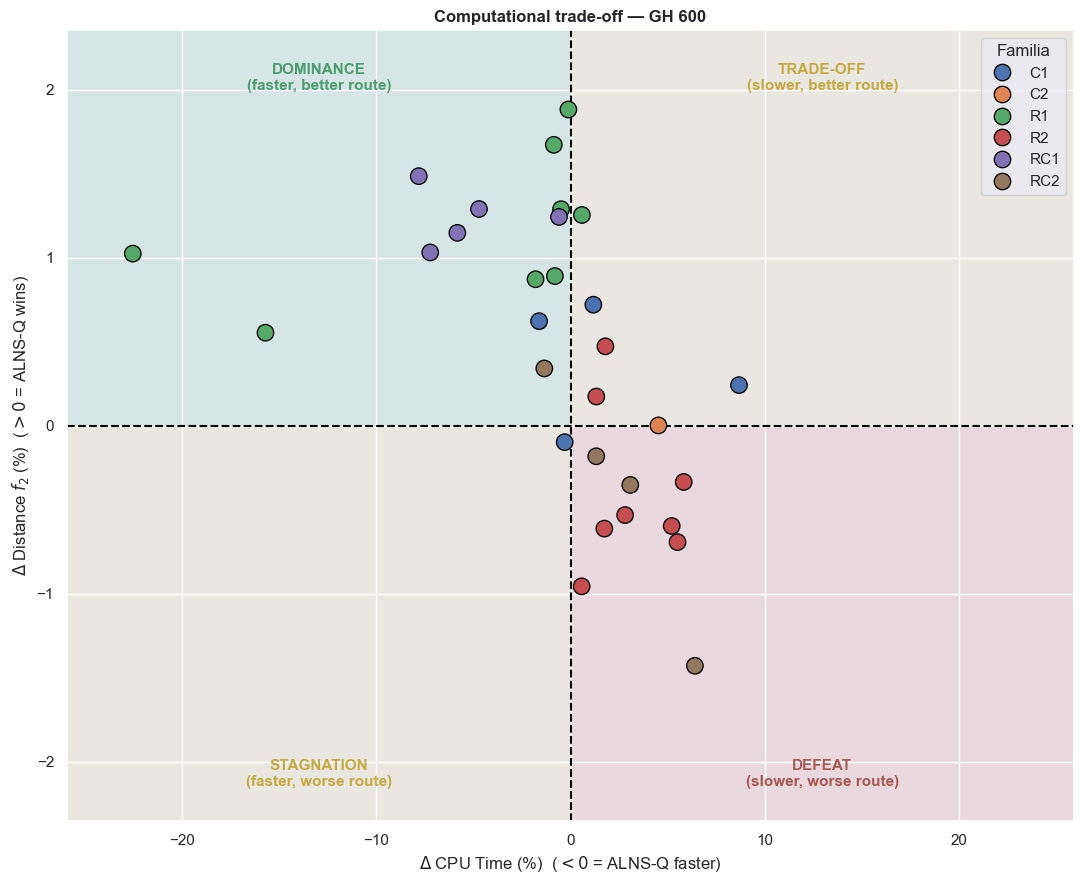

In [13]:
dt = df_final[df_final['CLASSIC_Vehiculos'] == df_final['QLEARNING_Vehiculos']].copy()

if len(dt) > 0:
    dt['dTime%'] = ((dt['QLEARNING_Tiempo_s'] - dt['CLASSIC_Tiempo_s']) / dt['CLASSIC_Tiempo_s']) * 100
    dt['dDist%'] = ((dt['CLASSIC_Distancia'] - dt['QLEARNING_Distancia']) / dt['CLASSIC_Distancia']) * 100
    fig, ax = plt.subplots(figsize=(11,9))
    xmax = max(abs(dt['dTime%']).max(), 1) * 1.15
    ymax = max(abs(dt['dDist%']).max(), 0.1) * 1.25

    ax.fill_between([-xmax,0],[0,0],[ymax,ymax], color=C_QL, alpha=0.10, zorder=0)
    ax.fill_between([0,xmax],[-ymax,-ymax],[0,0], color=C_ALNS, alpha=0.10, zorder=0)
    ax.fill_between([0,xmax],[0,0],[ymax,ymax], color='#f1c40f', alpha=0.07, zorder=0)
    ax.fill_between([-xmax,0],[-ymax,-ymax],[0,0], color='#f1c40f', alpha=0.07, zorder=0)
    ax.axhline(0, color='black', ls='--'); ax.axvline(0, color='black', ls='--')
    q = dict(fontsize=11, fontweight='bold', alpha=0.75, ha='center', va='center')
    ax.text(-xmax*0.5, ymax*0.88, 'DOMINANCE\n(faster, better route)', color='#1e8449', **q)
    ax.text( xmax*0.5, ymax*0.88, 'TRADE-OFF\n(slower, better route)', color='#b7950b', **q)
    ax.text(-xmax*0.5,-ymax*0.88, 'STAGNATION\n(faster, worse route)', color='#b7950b', **q)
    ax.text( xmax*0.5,-ymax*0.88, 'DEFEAT\n(slower, worse route)', color='#922b21', **q)
    sns.scatterplot(data=dt, x='dTime%', y='dDist%', hue='Familia', s=140, edgecolor='black', ax=ax, zorder=3)
    ax.set_xlim(-xmax,xmax); ax.set_ylim(-ymax,ymax)
    ax.set_xlabel('$\\Delta$ CPU Time (%)  ($<0$ = ALNS-Q faster)')
    ax.set_ylabel('$\\Delta$ Distance $f_2$ (%)  ($>0$ = ALNS-Q wins)')
    ax.set_title(f'Computational trade-off — GH {SIZE}', fontweight='bold')
    plt.tight_layout(); plt.savefig(f"{OUTDIR}/tradeoff.png", bbox_inches='tight'); plt.show()
else:
    print("Sin instancias de flota igual para el trade-off.")

### Tests estadísticos (esta campaña)
Wilcoxon pareado ALNS vs ALNS-Q para $f_1$, $f_2$ y tiempo.

In [14]:
def wtest(a, b, label):
    try:
        stat, p = wilcoxon(a, b, zero_method='wilcox')
        print(f"[Wilcoxon] {label}: stat={stat:.4f}, p={p:.6f} -> {'SIGNIFICATIVO' if p<0.05 else 'no significativo'}")
    except Exception as e:
        print(f"[Wilcoxon] {label}: no aplicable ({e})")

print(f"===== TESTS ESTADISTICOS — GH {SIZE} =====")

# Vehiculos utilizados f1
wtest(df_final['CLASSIC_Vehiculos'], df_final['QLEARNING_Vehiculos'], "f1 flota")

# GAP de distancia sobre el BKS
if tiene_bks:
    dvalid = df_final.dropna(subset=['CLASSIC_GAP_f2(%)','QLEARNING_GAP_f2(%)'])
    if len(dvalid) > 0:
        wtest(dvalid['CLASSIC_GAP_f2(%)'], dvalid['QLEARNING_GAP_f2(%)'], f"f2 GAP (n={len(dvalid)})")
    else:
        print("[Wilcoxon] f2 GAP: sin instancias validas en este tamano")

# Comparativa directa de distancias f2
dsame = df_final[df_final['CLASSIC_Vehiculos'] == df_final['QLEARNING_Vehiculos']]
if len(dsame) > 0:
    wtest(dsame['CLASSIC_Distancia'], dsame['QLEARNING_Distancia'],
          f"f2 directo (misma flota, n={len(dsame)})")
else:
    print("[Wilcoxon] f2 directo: sin instancias de flota empatada")

# Tiempos de ejecucion en CPU
wtest(df_final['CLASSIC_Tiempo_s'], df_final['QLEARNING_Tiempo_s'], "tiempo CPU")

===== TESTS ESTADISTICOS — GH 600 =====
[Wilcoxon] f1 flota: stat=9.5000, p=0.000004 -> SIGNIFICATIVO
[Wilcoxon] f2 GAP (n=12): stat=33.0000, p=0.677246 -> no significativo
[Wilcoxon] f2 directo (misma flota, n=30): stat=100.0000, p=0.005383 -> SIGNIFICATIVO
[Wilcoxon] tiempo CPU: stat=649.0000, p=0.050208 -> no significativo
